# 02c - Chignolin CV Metric Supervision

Lean workflow: train one CV backbone, decode `dV = W @ CV` with no bias, then evaluate single-CV and linear-combo metric decoders.


In [1]:
# Requires: pip install -e .

import itertools
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

from course_project.models.cv_tm_predictor import BackboneModel, LinearBackboneModel
from course_project.peptide import load_target_table
from course_project.peptide_tm import (
    build_metric_dataset,
    build_train_val_test_split,
    extract_cv_sequences,
    metric_stats_from_train_mutants,
    prediction_stats,
    release_cuda_memory,
    run_sim_epoch,
)
from course_project.plotting import PAPER_COLORS, apply_editorial_style, paper_caption, style_axes
from course_project.utils import resolve_device

apply_editorial_style()


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Config.

device = torch.device(resolve_device('cuda'))
force_train = False
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('device:', device)
print('seed:', seed)

backbone_type = 'linear'  # 'linear' or 'attention'
descriptor_token_dim = 32
base_run_name = f'chignolin_cv_tm_{backbone_type}_edge_stats_cv_to_dv_no_bias'
run_dir = Path('../results') / base_run_name / 'run'
run_dir.mkdir(parents=True, exist_ok=True)

target_metric_names = ['Tm', 'log_mfpt', 'log_mfpt_ratio', 'hlda_evalue']

history = 1
frames_per_traj = 20000
take_every_kth_frame = 1
train_mutant_count = 5
val_mutant_count = 15
hidden_size = 128
CVs = 4
token_sizes = (320, 80, 20, CVs)
heads = 1
transformer_layers = 2
pre_pyramid_layers = 2
dropout = 0.0
batch_size = 64
weight_decay = 1e-5
sim_learning_rate = 1e-4
sim_epochs = 20
sim_early_stop_patience = 3
selection_gap_penalty = 0.5
cls_weight = 0.1
time_lag_steps = 0

cfg = {
    'seed': seed,
    'history': history,
    'frames_per_traj': frames_per_traj,
    'take_every_kth_frame': take_every_kth_frame,
    'train_mutant_count': train_mutant_count,
    'val_mutant_count': val_mutant_count,
    'backbone_type': backbone_type,
    'hidden_size': hidden_size,
    'descriptor_token_dim': descriptor_token_dim,
    'linear_backbone_pooling': 'mean_std_max',
    'linear_backbone_descriptor_identity': True,
    'linear_backbone_token_mlp': 'linear_gelu_linear_gelu',
    'CVs': CVs,
    'token_sizes': token_sizes,
    'heads': heads,
    'transformer_layers': transformer_layers,
    'pre_pyramid_layers': pre_pyramid_layers,
    'dropout': dropout,
    'batch_size': batch_size,
    'weight_decay': weight_decay,
    'sim_learning_rate': sim_learning_rate,
    'sim_epochs': sim_epochs,
    'selection_gap_penalty': selection_gap_penalty,
    'cls_weight': cls_weight,
    'time_lag_steps': time_lag_steps,
}
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items()}, indent=2))


device: cuda
seed: 292906638
{
  "seed": 292906638,
  "history": 1,
  "frames_per_traj": 20000,
  "take_every_kth_frame": 1,
  "train_mutant_count": 5,
  "val_mutant_count": 15,
  "backbone_type": "linear",
  "hidden_size": 128,
  "descriptor_token_dim": 32,
  "linear_backbone_pooling": "mean_std_max",
  "linear_backbone_descriptor_identity": true,
  "linear_backbone_token_mlp": "linear_gelu_linear_gelu",
  "CVs": 4,
  "token_sizes": [
    320,
    80,
    20,
    4
  ],
  "heads": 1,
  "transformer_layers": 2,
  "pre_pyramid_layers": 2,
  "dropout": 0.0,
  "batch_size": 64,
  "weight_decay": 1e-05,
  "sim_learning_rate": 0.0001,
  "sim_epochs": 20,
  "selection_gap_penalty": 0.5,
  "cls_weight": 0.1,
  "time_lag_steps": 0
}


In [3]:
# Data.

packed = torch.load('../data/peptide/hlda_trajectories_compact.pt', map_location='cpu', weights_only=False)
x_all = packed.get('x_all', packed.get('x')).float()
time_all = packed.get('time_all', packed.get('time')).long()
offsets = packed.get('offsets', packed.get('traj_offsets')).long()
labels = packed['labels'].long()
mutants = packed['mutants']
feature_names = [str(name) for name in packed['feature_names']]
uniq_mutants_all = sorted(set(str(m) for m in mutants))
n_feat = int(x_all.shape[1])
distance_descriptor_indices = [i for i, name in enumerate(feature_names) if name.startswith('d') and name[1:].isdigit()]
distance_descriptor_names = [feature_names[i] for i in distance_descriptor_indices]
distance_descriptor_pairs = [(int(name[1]), int(name[2])) for name in distance_descriptor_names]
max_residue_index = max(max(pair) for pair in distance_descriptor_pairs)
distance_descriptor_metadata = torch.tensor(
    [
        [
            i / max_residue_index,
            j / max_residue_index,
            abs(j - i) / max_residue_index,
        ]
        for i, j in distance_descriptor_pairs
    ],
    dtype=torch.float32,
)

target_df = load_target_table(
    '../data/peptide/Tm.csv',
    '../data/peptide/mfpt_slice_thr0p34_tF0p25_tU0p57.csv',
    '../data/peptide/hlda_evalues_thr0p34_tF0p25_tU0p57.csv',
)
target_df['log_mfpt'] = np.log(target_df['mfpt'].astype(float))
uniq_mutants = [m for m in uniq_mutants_all if m in set(target_df['mutant'].astype(str))]

print('features:', n_feat)
print('distance descriptors used as edge-like CV tokens:', len(distance_descriptor_indices), distance_descriptor_names)
print('edge-like metadata columns: residue_i_norm, residue_j_norm, sequence_separation_norm')
print('usable mutants:', len(uniq_mutants))
display(target_df.head())


features: 29
distance descriptors used as edge-like CV tokens: 28 ['d03', 'd04', 'd05', 'd06', 'd07', 'd08', 'd09', 'd14', 'd15', 'd16', 'd17', 'd18', 'd19', 'd25', 'd26', 'd27', 'd28', 'd29', 'd36', 'd37', 'd38', 'd39', 'd47', 'd48', 'd49', 'd58', 'd59', 'd69']
edge-like metadata columns: residue_i_norm, residue_j_norm, sequence_separation_norm
usable mutants: 37


,mutant,Tm,mfpt,mfpt_ratio,log_mfpt_ratio,hlda_evalue,log_mfpt
0,WT,407.0,6.252921e+05,1.000000,0.000000,4919.890072,13.345974
1,D2N,420.0,3.952522e+05,0.632108,-0.458695,6592.658671,12.887279
2,D2A,394.0,8.198605e+05,1.311164,0.270915,6533.154022,13.616889
3,Y9E,290.0,4.443935e+04,0.071070,-2.644093,2720.063395,10.701881
4,T7Q,403.0,1.115225e+06,1.783526,0.578592,7664.947324,13.924566


In [4]:
# Helpers.

def build_backbone():
    if backbone_type == 'linear':
        return LinearBackboneModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            dropout=dropout,
            descriptor_token_dim=descriptor_token_dim,
            descriptor_indices=distance_descriptor_indices,
            descriptor_metadata=distance_descriptor_metadata,
        ).to(device)
    if backbone_type == 'attention':
        return BackboneModel(
            feat_dim=n_feat,
            history=history,
            hidden=hidden_size,
            token_sizes=token_sizes,
            heads=heads,
            token_layers=transformer_layers,
            dropout=dropout,
            pre_pyramid_layers=pre_pyramid_layers,
            linear_cv_decoder=True,
        ).to(device)
    raise ValueError(f'Unknown backbone_type={backbone_type!r}')


def build_pooled_feature_df(metric_dataset, metric_name, summary_type='mean'):
    rows = []
    for item in metric_dataset:
        seq = item['cv_seq'].cpu().numpy()
        pooled = seq.mean(axis=0) if summary_type == 'mean' else np.median(seq, axis=0)
        row = {'mutant': item['mutant'], metric_name: float(item['target_value']), 'summary_type': summary_type}
        for i, value in enumerate(pooled, start=1):
            row[f'cv_{i}'] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


def fit_linear_coefficients(train_df, feature_cols, target_col):
    X = train_df[feature_cols].to_numpy(dtype=float)
    y = train_df[target_col].to_numpy(dtype=float)
    return np.linalg.lstsq(np.column_stack([np.ones(len(X)), X]), y, rcond=None)[0]


def predict_linear_df(df, feature_cols, coef, metric_name):
    X = df[feature_cols].to_numpy(dtype=float)
    pred = np.column_stack([np.ones(len(X)), X]) @ coef
    out = df[['mutant', metric_name]].copy()
    out[f'pred_{metric_name}'] = pred
    return out


def fit_best_single_cv_decoder(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    rows = []
    for col in cv_cols:
        coef = fit_linear_coefficients(train_df, [col], metric_name)
        rows.append(linear_decoder_payload('single_cv', col, [col], coef, train_df, val_df, test_df, metric_name))
    return sorted(rows, key=lambda row: (row['val_stats']['rmse'], row['val_stats']['mae'], -row['val_stats']['r2']))[0]


def fit_linear_combo_decoder(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    rows = []
    for subset_size in range(1, len(cv_cols) + 1):
        for subset in itertools.combinations(cv_cols, subset_size):
            subset = list(subset)
            coef = fit_linear_coefficients(train_df, subset, metric_name)
            rows.append(linear_decoder_payload('linear_combo', ' + '.join(subset), subset, coef, train_df, val_df, test_df, metric_name))
    return sorted(rows, key=lambda row: (row['val_stats']['rmse'], row['val_stats']['mae'], -row['val_stats']['r2']))[0]


def adjusted_r2_score(payload):
    train_r2 = float(payload['train_stats']['r2'])
    val_r2 = float(payload['val_stats']['r2'])
    if not np.isfinite(val_r2):
        return (float('inf'), float('inf'), float('inf'))
    gap = max(0.0, train_r2 - val_r2) if np.isfinite(train_r2) else 0.0
    adjusted_r2 = val_r2 - selection_gap_penalty * gap
    payload['selection_score'] = adjusted_r2
    return (-adjusted_r2, float(payload['val_stats']['rmse']), float(payload['val_stats']['mae']))


def fit_best_single_cv_by_r2_rmse(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    rows = []
    for col in cv_cols:
        coef = fit_linear_coefficients(train_df, [col], metric_name)
        rows.append(linear_decoder_payload('single_cv', col, [col], coef, train_df, val_df, test_df, metric_name))
    return sorted(rows, key=adjusted_r2_score)[0]


def fit_best_combo_by_r2_rmse(train_df, val_df, test_df, metric_name):
    cv_cols = [c for c in train_df.columns if c.startswith('cv_')]
    rows = []
    for subset_size in range(1, len(cv_cols) + 1):
        for subset in itertools.combinations(cv_cols, subset_size):
            subset = list(subset)
            coef = fit_linear_coefficients(train_df, subset, metric_name)
            rows.append(linear_decoder_payload('linear_combo', ' + '.join(subset), subset, coef, train_df, val_df, test_df, metric_name))
    return sorted(rows, key=adjusted_r2_score)[0]


def linear_decoder_payload(decoder, detail, feature_cols, coef, train_df, val_df, test_df, metric_name):
    train_pred = predict_linear_df(train_df, feature_cols, coef, metric_name)
    val_pred = predict_linear_df(val_df, feature_cols, coef, metric_name)
    test_pred = predict_linear_df(test_df, feature_cols, coef, metric_name)
    return {
        'decoder': decoder,
        'decoder_detail': detail,
        'feature_cols': list(feature_cols),
        'coef': np.asarray(coef, dtype=float).tolist(),
        'train_pred_df': train_pred,
        'val_pred_df': val_pred,
        'test_pred_df': test_pred,
        'train_stats': prediction_stats(train_pred, metric_name),
        'val_stats': prediction_stats(val_pred, metric_name),
        'test_stats': prediction_stats(test_pred, metric_name),
    }


def compact_formula(payload):
    if payload['decoder'] == 'single_cv':
        return payload['decoder_detail']
    coef = np.asarray(payload['coef'], dtype=float)
    weights = coef[1:]
    scale = max(float(np.max(np.abs(weights))), 1e-12)
    return ' '.join(f'{w / scale:+.2f}*{col}' for w, col in zip(weights, payload['feature_cols']))


def descriptor_residue_indices(feature_name):
    name = str(feature_name)
    if name.startswith('d') and name[1:].isdigit():
        return [int(ch) for ch in name[1:]]
    return []


def aggregate_residue_weights(feature_names, weights):
    rows = []
    for feature_name, weight in zip(feature_names, np.asarray(weights, dtype=float)):
        for residue_index in descriptor_residue_indices(feature_name):
            rows.append({'residue_index': residue_index, 'abs_weight': abs(float(weight))})
    return pd.DataFrame(rows).groupby('residue_index', as_index=False)['abs_weight'].sum().sort_values('abs_weight', ascending=False)


In [ ]:
# Split and train one no-bias CV backbone.

split_payload = build_train_val_test_split(
    run_seed=seed,
    uniq_mutants=uniq_mutants,
    train_mutant_count=train_mutant_count,
    val_mutant_count=val_mutant_count,
    mutants=mutants,
    history=history,
    time_lag_steps=time_lag_steps,
    frames_per_traj=frames_per_traj,
    take_every_kth_frame=take_every_kth_frame,
    x_all=x_all,
    time_all=time_all,
    offsets=offsets,
    labels=labels,
    n_feat=n_feat,
)

backbone_ckpt = run_dir / 'backbone.pt'
metric_ckpts = {metric_name: run_dir / f'backbone_best_{metric_name}.pt' for metric_name in target_metric_names}
sim_history_csv = run_dir / 'sim_history.csv'
config_json = run_dir / 'config.json'
config_json.write_text(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in cfg.items()}, indent=2))

release_cuda_memory()
backbone = build_backbone()
opt = torch.optim.AdamW(backbone.parameters(), lr=sim_learning_rate, weight_decay=weight_decay)
train_loader = DataLoader(TensorDataset(split_payload['train_x'], split_payload['train_dv'], split_payload['train_cls']), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(TensorDataset(split_payload['val_x'], split_payload['val_dv'], split_payload['val_cls']), batch_size=batch_size, shuffle=False, drop_last=False)

def epoch_metric_summary():
    train_cv_sequences_now = extract_cv_sequences(backbone, split_payload['train_x'], split_payload['train_samples_df'], batch_size=batch_size, device=device)
    val_cv_sequences_now = extract_cv_sequences(backbone, split_payload['val_x'], split_payload['val_samples_df'], batch_size=batch_size, device=device)
    rows = []
    for metric_name in target_metric_names:
        metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, metric_name)
        train_metric_dataset = build_metric_dataset(train_cv_sequences_now, metric_stats, target_df, metric_name)
        val_metric_dataset = build_metric_dataset(val_cv_sequences_now, metric_stats, target_df, metric_name)
        train_pooled = build_pooled_feature_df(train_metric_dataset, metric_name, summary_type='mean')
        val_pooled = build_pooled_feature_df(val_metric_dataset, metric_name, summary_type='mean')
        single = fit_best_single_cv_by_r2_rmse(train_pooled, val_pooled, val_pooled, metric_name)
        combo = fit_best_combo_by_r2_rmse(train_pooled, val_pooled, val_pooled, metric_name)
        rows.append((metric_name, single, combo))
    return rows

history_rows = []
best_val = float('inf')
best_metric_score = {metric_name: (float('inf'), float('inf'), float('inf')) for metric_name in target_metric_names}
bad_epochs = 0
for epoch in range(1, sim_epochs + 1):
    train_info = run_sim_epoch(backbone, train_loader, device=device, cls_weight=cls_weight, opt=opt)
    val_info = run_sim_epoch(backbone, val_loader, device=device, cls_weight=cls_weight, opt=None)
    metric_rows = epoch_metric_summary()
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_info.items()}, **{f'val_{k}': v for k, v in val_info.items()}}
    metric_text_parts = []
    for metric_name, single, combo in metric_rows:
        row[f'{metric_name}_single_val_rmse'] = single['val_stats']['rmse']
        row[f'{metric_name}_single_val_r2'] = single['val_stats']['r2']
        row[f'{metric_name}_single_val_pearson'] = single['val_stats']['pearson']
        row[f'{metric_name}_combo_val_rmse'] = combo['val_stats']['rmse']
        row[f'{metric_name}_combo_val_r2'] = combo['val_stats']['r2']
        row[f'{metric_name}_combo_val_pearson'] = combo['val_stats']['pearson']
        row[f'{metric_name}_combo'] = compact_formula(combo)
        combo_score = adjusted_r2_score(combo)
        if combo_score < best_metric_score[metric_name]:
            best_metric_score[metric_name] = combo_score
            torch.save({
                'seed': seed,
                'epoch': epoch,
                'metric': metric_name,
                'val_rmse': combo['val_stats']['rmse'],
                'val_r2': combo['val_stats']['r2'],
                'val_pearson': combo['val_stats']['pearson'],
                'selection_score': combo.get('selection_score', float('nan')),
                'selection_gap_penalty': selection_gap_penalty,
                'combo': compact_formula(combo),
                'model_state_dict': backbone.state_dict(),
            }, metric_ckpts[metric_name])
        metric_text_parts.append(
            f"{metric_name}: single {single['decoder_detail']} RMSE={single['val_stats']['rmse']:.2f}, R2={single['val_stats']['r2']:.2f}; "
            f"combo RMSE={combo['val_stats']['rmse']:.2f}, R2={combo['val_stats']['r2']:.2f}, sel={combo.get('selection_score', float('nan')):.2f}, {compact_formula(combo)}"
        )
    history_rows.append(row)
    metric_text = ' | '.join(metric_text_parts)
    print(f"epoch {epoch:03d} train={train_info['sim_loss']:.5f} val={val_info['sim_loss']:.5f} | {metric_text}")
    if val_info['sim_loss'] < best_val - 1e-8:
        best_val = float(val_info['sim_loss'])
        bad_epochs = 0
        torch.save({'seed': seed, 'epoch': epoch, 'model_state_dict': backbone.state_dict()}, backbone_ckpt)
    else:
        bad_epochs += 1
    if bad_epochs >= sim_early_stop_patience:
        break

sim_history_df = pd.DataFrame(history_rows)
sim_history_df.to_csv(sim_history_csv, index=False)
sim_best_payload = torch.load(backbone_ckpt, map_location='cpu', weights_only=False)
backbone.load_state_dict(sim_best_payload['model_state_dict'])
backbone.eval()

fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.0))
ax.plot(sim_history_df['epoch'], sim_history_df['train_sim_loss'], color=PAPER_COLORS['blue'], label='train')
ax.plot(sim_history_df['epoch'], sim_history_df['val_sim_loss'], color=PAPER_COLORS['red'], label='val')
style_axes(ax, xlabel='epoch', ylabel='simulator loss', legend=True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
for metric_name in target_metric_names:
    val_metric_values = target_df[target_df['mutant'].astype(str).isin(split_payload['val_mutants'])][metric_name].to_numpy(dtype=float)
    rmse_scale = max(float(np.nanstd(val_metric_values)), 1e-12)
    axes[0].plot(sim_history_df['epoch'], sim_history_df[f'{metric_name}_combo_val_rmse'] / rmse_scale, marker='o', lw=1.4, label=metric_name)
    axes[1].plot(sim_history_df['epoch'], sim_history_df[f'{metric_name}_combo_val_r2'], marker='o', lw=1.4, label=metric_name)
style_axes(axes[0], xlabel='epoch', ylabel='best combo val RMSE / val std', legend=True)
style_axes(axes[1], xlabel='epoch', ylabel='best combo val R2', legend=True)
plt.tight_layout()
plt.show()


epoch 001 train=1.00834 val=0.97414 | Tm: single cv_4 RMSE=36.82, R2=0.58; combo RMSE=36.82, R2=0.58, sel=0.52, +1.00*cv_4 | log_mfpt: single cv_2 RMSE=1.85, R2=0.43; combo RMSE=1.90, R2=0.55, sel=0.33, +1.00*cv_2 +0.18*cv_4 | log_mfpt_ratio: single cv_2 RMSE=1.85, R2=0.43; combo RMSE=1.90, R2=0.55, sel=0.33, +1.00*cv_2 +0.18*cv_4 | hlda_evalue: single cv_1 RMSE=1907.20, R2=0.57; combo RMSE=2383.79, R2=0.65, sel=0.47, -1.00*cv_1 +0.72*cv_2 +0.38*cv_3
epoch 002 train=0.96139 val=0.95451 | Tm: single cv_4 RMSE=36.88, R2=0.35; combo RMSE=74.10, R2=0.95, sel=0.92, -1.00*cv_2 -0.93*cv_3 +0.28*cv_4 | log_mfpt: single cv_3 RMSE=1.79, R2=0.48; combo RMSE=2.23, R2=0.50, sel=0.37, -1.00*cv_1 +0.40*cv_4 | log_mfpt_ratio: single cv_3 RMSE=1.79, R2=0.48; combo RMSE=2.23, R2=0.50, sel=0.37, -1.00*cv_1 +0.40*cv_4 | hlda_evalue: single cv_3 RMSE=1356.32, R2=0.73; combo RMSE=2072.49, R2=0.82, sel=0.77, -1.00*cv_1 +0.31*cv_4
epoch 003 train=0.94300 val=0.94654 | Tm: single cv_4 RMSE=38.34, R2=0.25; comb

In [ ]:
# Extract CV sequences and evaluate metric decoders.

pred_rows = []
metric_payloads = []
for metric_name in target_metric_names:
    metric_best_payload = torch.load(metric_ckpts[metric_name], map_location='cpu', weights_only=False)
    backbone.load_state_dict(metric_best_payload['model_state_dict'])
    backbone.eval()

    train_cv_sequences = extract_cv_sequences(backbone, split_payload['train_x'], split_payload['train_samples_df'], batch_size=batch_size, device=device)
    val_cv_sequences = extract_cv_sequences(backbone, split_payload['val_x'], split_payload['val_samples_df'], batch_size=batch_size, device=device)
    test_cv_sequences = extract_cv_sequences(backbone, split_payload['test_x'], split_payload['test_samples_df'], batch_size=batch_size, device=device)

    metric_stats = metric_stats_from_train_mutants(split_payload['train_mutants'], target_df, metric_name)
    train_metric_dataset = build_metric_dataset(train_cv_sequences, metric_stats, target_df, metric_name)
    val_metric_dataset = build_metric_dataset(val_cv_sequences, metric_stats, target_df, metric_name)
    test_metric_dataset = build_metric_dataset(test_cv_sequences, metric_stats, target_df, metric_name)

    train_pooled = build_pooled_feature_df(train_metric_dataset, metric_name, summary_type='mean')
    val_pooled = build_pooled_feature_df(val_metric_dataset, metric_name, summary_type='mean')
    test_pooled = build_pooled_feature_df(test_metric_dataset, metric_name, summary_type='mean')
    for payload in [
        fit_best_single_cv_by_r2_rmse(train_pooled, val_pooled, test_pooled, metric_name),
        fit_best_combo_by_r2_rmse(train_pooled, val_pooled, test_pooled, metric_name),
    ]:
        payload['metric'] = metric_name
        payload['best_epoch'] = int(metric_best_payload['epoch'])
        payload['best_epoch_val_rmse'] = float(metric_best_payload['val_rmse'])
        payload['best_epoch_val_r2'] = float(metric_best_payload['val_r2'])
        payload['best_epoch_selection_score'] = float(metric_best_payload.get('selection_score', float('nan')))
        metric_payloads.append(payload)
        pred_rows.append({
            'metric': metric_name,
            'best_epoch': int(metric_best_payload['epoch']),
            'best_epoch_combo_val_rmse': float(metric_best_payload['val_rmse']),
            'best_epoch_combo_val_r2': float(metric_best_payload['val_r2']),
            'best_epoch_selection_score': float(metric_best_payload.get('selection_score', float('nan'))),
            'decoder': payload['decoder'],
            'decoder_detail': payload['decoder_detail'],
            'formula': compact_formula(payload),
            'train_rmse': payload['train_stats']['rmse'],
            'val_rmse': payload['val_stats']['rmse'],
            'val_r2': payload['val_stats']['r2'],
            'val_pearson': payload['val_stats']['pearson'],
            'test_rmse': payload['test_stats']['rmse'],
            'test_r2': payload['test_stats']['r2'],
            'test_pearson': payload['test_stats']['pearson'],
            'test_spearman': payload['test_stats']['spearman'],
        })

metric_prediction_summary_df = pd.DataFrame(pred_rows).sort_values(['metric', 'val_r2'], ascending=[True, False]).reset_index(drop=True)
metric_prediction_summary_df.to_csv(run_dir / 'metric_prediction_summary.csv', index=False)
display(metric_prediction_summary_df.round(4))

# Leave the notebook on the simulator-best checkpoint for decoder inspection cells.
backbone.load_state_dict(sim_best_payload['model_state_dict'])
backbone.eval()


,metric,best_epoch,best_epoch_combo_val_rmse,best_epoch_combo_val_r2,best_epoch_selection_score,decoder,decoder_detail,formula,train_rmse,val_rmse,val_r2,val_pearson,test_rmse,test_r2,test_pearson,test_spearman
0,Tm,12,34.5549,0.9995,0.9995,linear_combo,cv_2 + cv_3 + cv_4,-0.63*cv_2 +1.00*cv_3 +0.61*cv_4,26.6930,34.5549,0.9995,0.7467,36.0538,0.3628,0.2767,0.1403
1,Tm,12,34.5549,0.9995,0.9995,single_cv,cv_2,cv_2,33.3162,30.5639,0.7256,0.6590,46.6937,0.1697,0.2823,0.3356
2,hlda_evalue,6,1950.7020,-0.0578,-0.3512,linear_combo,cv_1 + cv_2,+0.17*cv_1 -1.00*cv_2,1045.4656,1950.7020,-0.0578,0.3521,2182.1527,-1.2876,-0.2557,-0.2363
3,hlda_evalue,6,1950.7020,-0.0578,-0.3512,single_cv,cv_2,cv_2,1047.3028,1971.5429,-0.0676,0.2714,2072.8420,-1.1298,-0.2324,-0.2088
4,log_mfpt,13,2.0626,0.3756,0.2891,linear_combo,cv_1 + cv_2,-0.30*cv_1 -1.00*cv_2,1.2887,2.0626,0.3756,0.3129,2.0950,-0.4284,-0.2075,-0.2582
5,log_mfpt,13,2.0626,0.3756,0.2891,single_cv,cv_2,cv_2,1.2953,1.9806,0.3612,0.3686,2.2112,-0.4614,-0.1854,-0.2253
6,log_mfpt_ratio,13,2.0626,0.3756,0.2891,linear_combo,cv_1 + cv_2,-0.30*cv_1 -1.00*cv_2,1.2887,2.0626,0.3756,0.3129,2.0950,-0.4284,-0.2075,-0.2582
7,log_mfpt_ratio,13,2.0626,0.3756,0.2891,single_cv,cv_2,cv_2,1.2953,1.9806,0.3612,0.3686,2.2112,-0.4614,-0.1854,-0.2253


LinearBackboneModel(
  (desc_in): Linear(in_features=4, out_features=32, bias=True)
  (token_mlp): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): GELU(approximate='none')
  )
  (cv_net): Sequential(
    (0): Linear(in_features=96, out_features=320, bias=True)
    (1): Linear(in_features=320, out_features=80, bias=True)
    (2): Linear(in_features=80, out_features=20, bias=True)
    (3): Linear(in_features=20, out_features=4, bias=True)
  )
  (dv_head): Linear(in_features=4, out_features=29, bias=False)
  (cls_head): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

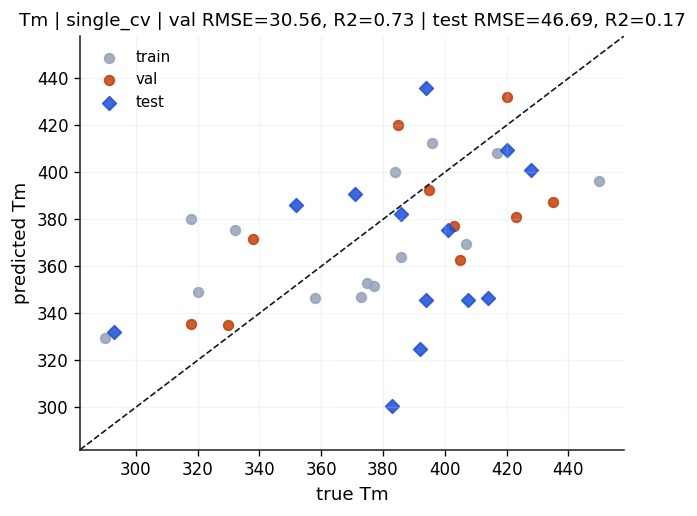

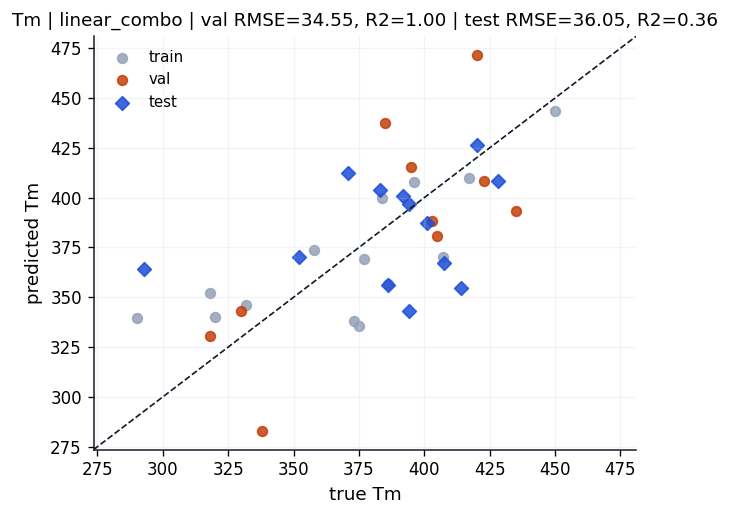

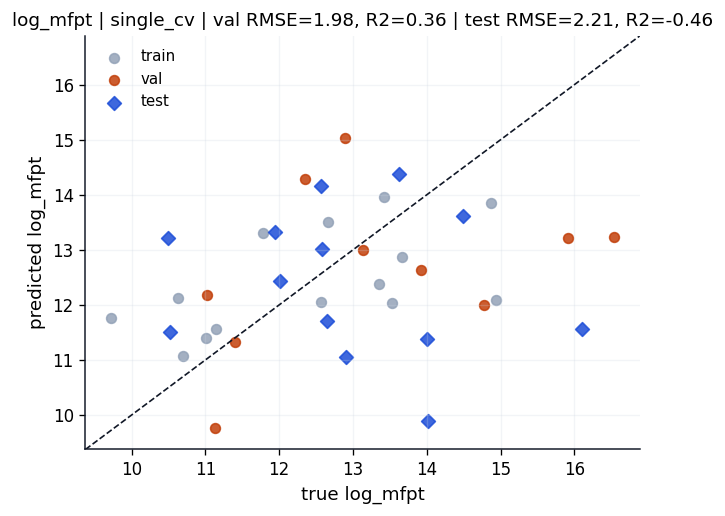

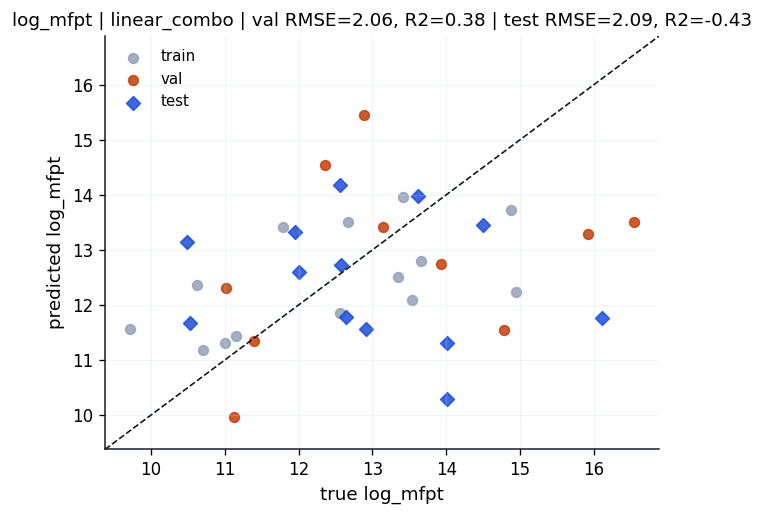

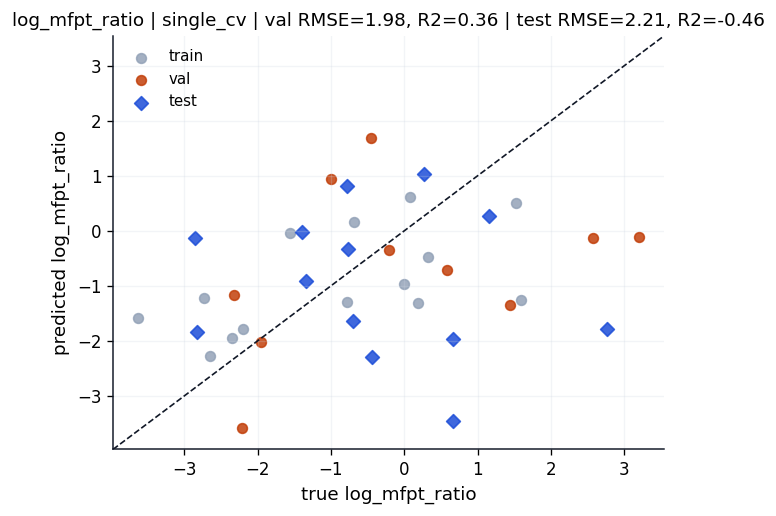

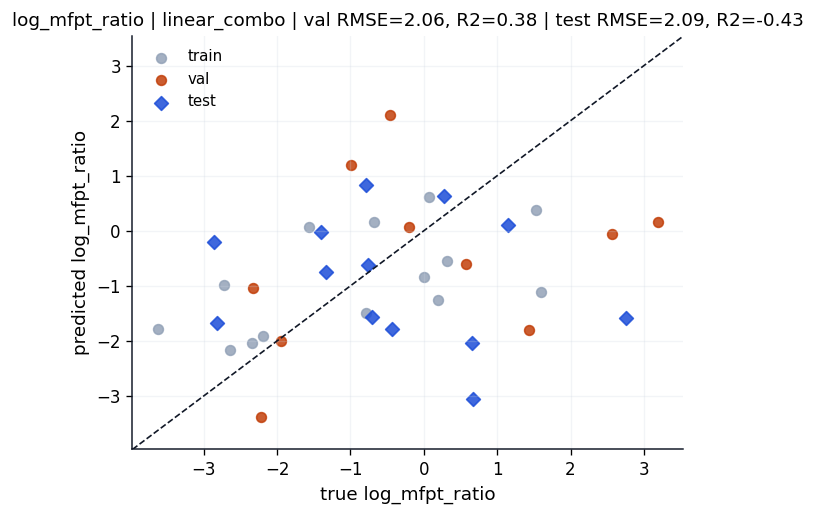

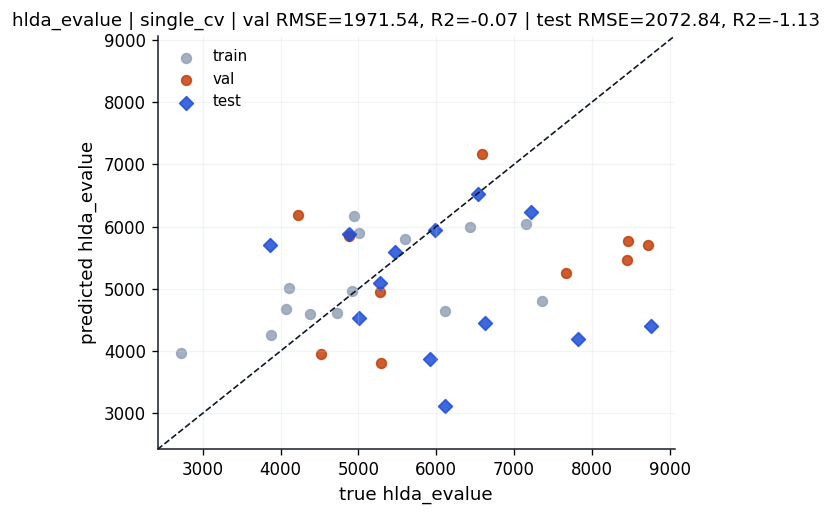

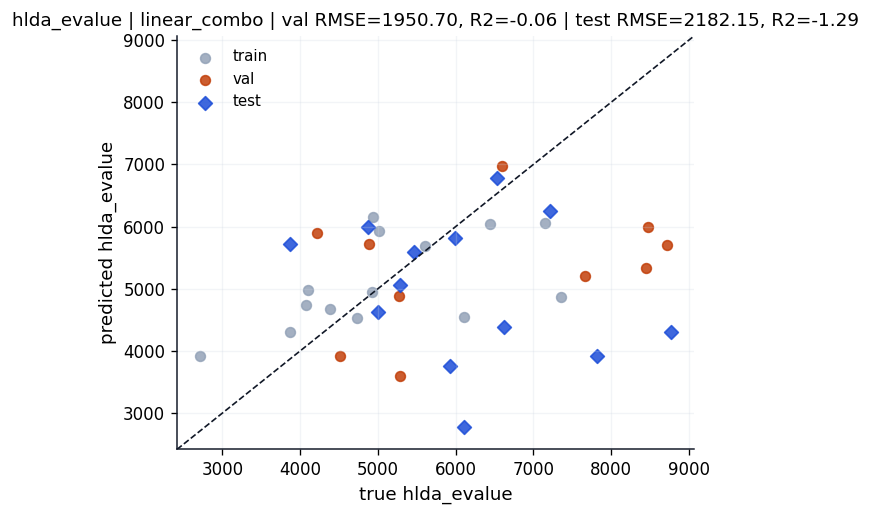

In [ ]:
# Metric prediction scatter.

for payload in metric_payloads:
    metric_name = payload['metric']
    fig, ax = plt.subplots(1, 1, figsize=(5.4, 4.4))
    for split_name, pred_df, color, marker in [
        ('train', payload['train_pred_df'], PAPER_COLORS['light'], 'o'),
        ('val', payload['val_pred_df'], PAPER_COLORS['orange'], 'o'),
        ('test', payload['test_pred_df'], PAPER_COLORS['blue'], 'D'),
    ]:
        ax.scatter(pred_df[metric_name], pred_df[f'pred_{metric_name}'], s=34, alpha=0.85, color=color, marker=marker, label=split_name)
    xy = pd.concat([payload['train_pred_df'], payload['val_pred_df'], payload['test_pred_df']], ignore_index=True)
    lo = float(np.nanmin(xy[[metric_name, f'pred_{metric_name}']].to_numpy(dtype=float)))
    hi = float(np.nanmax(xy[[metric_name, f'pred_{metric_name}']].to_numpy(dtype=float)))
    pad = 0.05 * (hi - lo + 1e-8)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=PAPER_COLORS['ink'], ls='--', lw=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(
        f"{metric_name} | {payload['decoder']} | val RMSE={payload['val_stats']['rmse']:.2f}, R2={payload['val_stats']['r2']:.2f} | "
        f"test RMSE={payload['test_stats']['rmse']:.2f}, R2={payload['test_stats']['r2']:.2f}"
    )
    style_axes(ax, xlabel=f'true {metric_name}', ylabel=f'predicted {metric_name}', legend=True)
    plt.tight_layout()
    plt.show()


No-bias simulator decoder weights: dV = W @ CV


,max_abs_descriptor_weight
cv_1,0.37100
cv_2,0.40861
cv_3,0.32512
cv_4,0.46778


,cv,feature,weight,abs_weight
0,cv_1,d69,0.37100,0.37100
1,cv_1,d59,0.34368,0.34368
2,cv_1,d49,0.31686,0.31686
3,cv_1,d39,0.25441,0.25441
4,cv_1,d29,0.24512,0.24512
5,cv_1,d58,0.23871,0.23871
6,cv_1,d19,0.21221,0.21221
7,cv_1,d25,0.20421,0.20421
8,cv_1,d48,0.19752,0.19752
9,cv_1,d26,0.18024,0.18024


Decoder weights aggregated by residue index


cv,cv_1,cv_2,cv_3,cv_4
residue_index,,,,
0,0.43951,1.40673,1.22591,1.12161
1,0.75143,1.18043,0.86753,0.99340
2,0.77718,1.07156,0.38501,0.58879
3,0.48002,1.25947,1.02443,0.94650
4,0.71018,1.13903,0.97416,0.97945
5,1.05937,1.25859,0.48391,1.02680
6,0.92422,1.35645,0.57977,1.11203
7,0.21196,1.22077,0.83659,0.95447
8,0.82510,1.10757,0.64590,0.75327


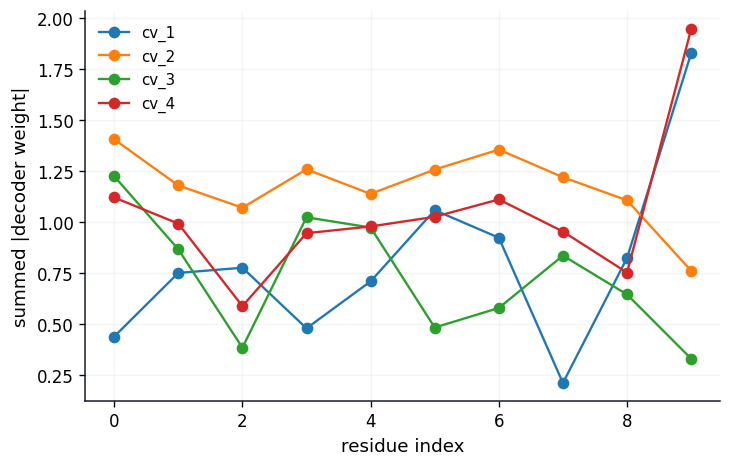

In [ ]:
# Simulator decoder weights: dV = W @ CV, no bias.

W = backbone.dv_head.weight.detach().cpu().numpy()
cv_labels = [f'cv_{i}' for i in range(1, W.shape[1] + 1)]
weight_df = pd.DataFrame(W, index=feature_names, columns=cv_labels)
paper_caption('No-bias simulator decoder weights: dV = W @ CV')
display(weight_df.abs().max(axis=0).rename('max_abs_descriptor_weight').to_frame().round(5))

top_rows = []
for cv_col in cv_labels:
    sub = weight_df[cv_col].abs().sort_values(ascending=False).head(10)
    for feature_name, abs_weight in sub.items():
        top_rows.append({'cv': cv_col, 'feature': feature_name, 'weight': weight_df.loc[feature_name, cv_col], 'abs_weight': abs_weight})
display(pd.DataFrame(top_rows).round(5))

residue_weight_rows = []
for cv_col in cv_labels:
    residue_df = aggregate_residue_weights(feature_names, weight_df[cv_col].to_numpy())
    residue_df['cv'] = cv_col
    residue_weight_rows.append(residue_df)
residue_weight_df = pd.concat(residue_weight_rows, ignore_index=True)
paper_caption('Decoder weights aggregated by residue index')
display(residue_weight_df.pivot(index='residue_index', columns='cv', values='abs_weight').fillna(0.0).round(5))

fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.0))
for cv_col in cv_labels:
    sub = residue_weight_df[residue_weight_df['cv'] == cv_col].sort_values('residue_index')
    ax.plot(sub['residue_index'], sub['abs_weight'], marker='o', lw=1.4, label=cv_col)
style_axes(ax, xlabel='residue index', ylabel='summed |decoder weight|', legend=True)
plt.tight_layout()
plt.show()


D2M: dV decoder decomposition, frame RMSE=0.963, accumulated cosine=0.440


,feature,true_accum_dv,pred_accum_dv,abs_error
0,d37,6.3656,4185.078613,4178.712891
1,d36,4.9557,3884.148682,3879.193115
2,d69,1.7479,-3052.229004,3053.976807
3,d27,9.1548,3026.149170,3016.994385
4,d47,2.1145,2629.304688,2627.190186
5,d38,7.1652,2610.937012,2603.771729
6,d59,1.2746,-2240.363770,2241.638428
7,d28,9.9211,2002.103638,1992.182373
8,d17,11.0294,1934.308228,1923.279053
9,d18,13.3365,1187.706421,1174.369873


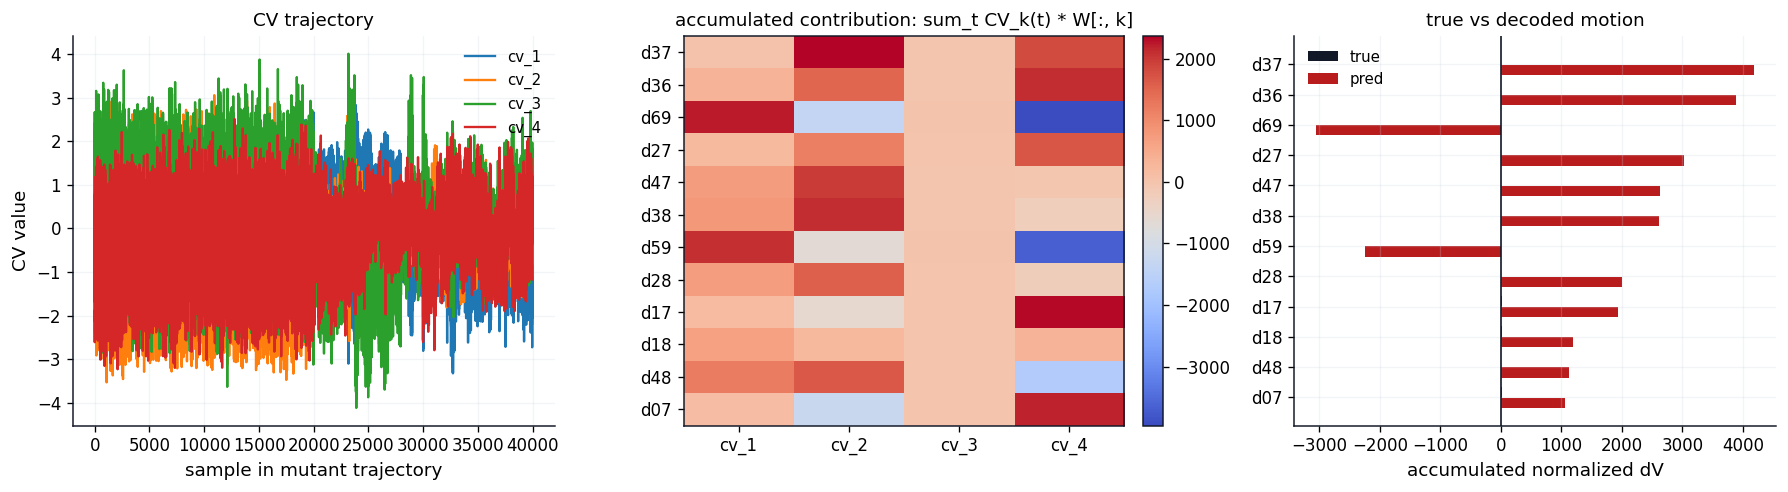

In [ ]:
# One mutant: what the CVs contribute to predicted descriptor motion.

test_cv_chunks = []
test_cv_loader = DataLoader(TensorDataset(split_payload['test_x']), batch_size=batch_size, shuffle=False, drop_last=False)
with torch.no_grad():
    for (xh,) in test_cv_loader:
        test_cv_chunks.append(backbone.encode_cv(xh.to(device)).detach().cpu())
test_cv_all = torch.cat(test_cv_chunks, dim=0).numpy()

test_samples_df = split_payload['test_samples_df'].reset_index(drop=True).copy()
test_dv = split_payload['test_dv'].detach().cpu().numpy()
inspect_mutant = str(split_payload['test_mutants'][0])
mutant_mask = test_samples_df['mutant'].astype(str).to_numpy() == inspect_mutant

cv_seq = test_cv_all[mutant_mask]
true_dv = test_dv[mutant_mask]
pred_dv = cv_seq @ W.T
per_cv_total = W * cv_seq.sum(axis=0)[None, :]
true_total = true_dv.sum(axis=0)
pred_total = pred_dv.sum(axis=0)

rmse_dv = float(np.sqrt(np.mean((pred_dv - true_dv) ** 2)))
cos_total = float(np.dot(pred_total, true_total) / (np.linalg.norm(pred_total) * np.linalg.norm(true_total) + 1e-12))
score = np.maximum(np.abs(pred_total), np.abs(true_total))
top_idx = np.argsort(score)[-12:][::-1]
top_features = [feature_names[i] for i in top_idx]

paper_caption(f'{inspect_mutant}: dV decoder decomposition, frame RMSE={rmse_dv:.3f}, accumulated cosine={cos_total:.3f}')
display(pd.DataFrame({
    'feature': top_features,
    'true_accum_dv': true_total[top_idx],
    'pred_accum_dv': pred_total[top_idx],
    'abs_error': np.abs(pred_total[top_idx] - true_total[top_idx]),
}).round(4))

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
for k, cv_label in enumerate(cv_labels):
    axes[0].plot(cv_seq[:, k], lw=1.4, label=cv_label)
style_axes(axes[0], xlabel='sample in mutant trajectory', ylabel='CV value', legend=True)
axes[0].set_title('CV trajectory')

img = axes[1].imshow(per_cv_total[top_idx, :], aspect='auto', cmap='coolwarm')
axes[1].set_xticks(range(len(cv_labels)), cv_labels)
axes[1].set_yticks(range(len(top_features)), top_features)
axes[1].set_title('accumulated contribution: sum_t CV_k(t) * W[:, k]')
fig.colorbar(img, ax=axes[1], fraction=0.046, pad=0.04)

y = np.arange(len(top_features))
axes[2].barh(y - 0.18, true_total[top_idx], height=0.34, color=PAPER_COLORS['ink'], label='true')
axes[2].barh(y + 0.18, pred_total[top_idx], height=0.34, color=PAPER_COLORS['red'], label='pred')
axes[2].axvline(0.0, color=PAPER_COLORS['ink'], lw=1.0)
axes[2].set_yticks(y, top_features)
axes[2].invert_yaxis()
style_axes(axes[2], xlabel='accumulated normalized dV', legend=True)
axes[2].set_title('true vs decoded motion')
plt.tight_layout()
plt.show()


Tm effective decoder weights: -0.63*cv_2 +1.00*cv_3 +0.61*cv_4


,feature,weight,abs_weight
8,d14,-126.53366,126.53366
2,d04,-118.85019,118.85019
1,d03,-110.22547,110.22547
3,d05,-106.72338,106.72338
9,d15,-104.03540,104.03540
10,d16,-94.59775,94.59775
4,d06,-93.91338,93.91338
5,d07,-91.62246,91.62246
11,d17,-78.41188,78.41188
14,d25,-61.51329,61.51329


,residue_index,abs_weight
0,0,591.28915
1,1,459.16612
5,5,347.99107
4,4,338.02437
6,6,320.80138
9,9,256.89886
7,7,228.13880
3,3,219.42878
2,2,183.03663
8,8,173.29108


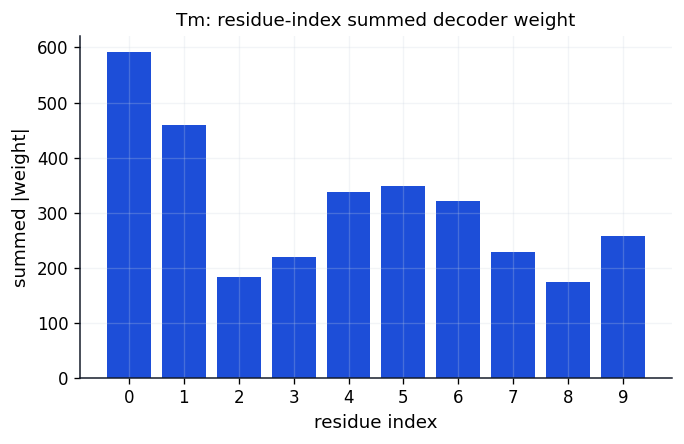

In [ ]:
# Tm summed decoder weights.

tm_payload = [p for p in metric_payloads if p['decoder'] == 'linear_combo' and p['metric'] == 'Tm'][0]
cols = tm_payload['feature_cols']
coef = np.asarray(tm_payload['coef'][1:], dtype=float)
idx = [int(col.split('_')[1]) - 1 for col in cols]
effective = W[:, idx] @ coef
eff_df = pd.DataFrame({'feature': feature_names, 'weight': effective, 'abs_weight': np.abs(effective)}).sort_values('abs_weight', ascending=False)
residue_eff_df = aggregate_residue_weights(feature_names, effective)

paper_caption(f"Tm effective decoder weights: {compact_formula(tm_payload)}")
display(eff_df.head(12).round(5))
display(residue_eff_df.round(5))

fig, ax = plt.subplots(1, 1, figsize=(5.8, 3.8))
residue_plot = residue_eff_df.sort_values('residue_index')
ax.bar(residue_plot['residue_index'].astype(str), residue_plot['abs_weight'], color=PAPER_COLORS['blue'])
ax.set_title('Tm: residue-index summed decoder weight')
style_axes(ax, xlabel='residue index', ylabel='summed |weight|')
plt.tight_layout()
plt.show()
